In [3]:
#Task 6
# Türkçe isim listenle aynı WaveNet'i eğit. Ürettiği isimlerden örnek ver,
# dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır. Türkçe'de bağlamı 8'e
# çıkarmak ne kazandırdı, yaz.

In [4]:
import random 
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
words = open('isimler_unique.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([55346, 8]) torch.Size([55346])
torch.Size([6951, 8]) torch.Size([6951])
torch.Size([6937, 8]) torch.Size([6937])


In [6]:
class Linear: #x⋅W^T + b = (B×fan_in)×(fan_in×fan_out) (fan_out) = (B×fan_out)  -> linear layer basically
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 ######
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__ (self,x):
        self.out= x @ self.weight
        if self.bias is not None:
            self.out+=self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d: #y = gamma(scale) * xhat(normalized_input) + beta(shift/bias)
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #backpropb params
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #ema params
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        #forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim,keepdim=True)
            xvar = x.var(dim,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean) / (xvar + self.eps)**0.5
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh: #just tanh(x)

    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []      


class Embedding: #emb = C[Xb]
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim)) #was C(lookup table) previous code

    def __call__(self,IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self,n):
        self.n = n

    def __call__(self,x):
        B, T, C = x.shape
        x = x.view(B,T//self.n,C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out 

    def parameters(self):
        return[]
    

class Sequential: 
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()] #collecting whole parameters from all layers 
        

In [7]:
torch.manual_seed(42)

In [8]:
n_embd = 24
n_hidden = 128

model = Sequential([ 
           Embedding(vocab_size, n_embd),
           FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
           FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
           FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
           Linear(n_hidden, vocab_size)])

#parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()

for p in parameters:
    p.requires_grad = True

print(f"{sum(p.nelement() for p in parameters)} parameters")    

77038 parameters


In [9]:
#optimization block
max_steps = 200000
batch_size = 32 
lossi = []

for i in range(max_steps):

    #picking our batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] 

    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb)

    #backward pass
    for p in parameters:
        p.grad = None #gradient reseting everytime
    loss.backward()

    #update rule with learning rate decay after 150k
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += lr * (-p.grad)

    #for curve
    if  i % 10000 == 0:
        print(f'{i:7d} / {max_steps:7d}: {loss.item():4f}')
    lossi.append(loss.log10().item())


      0 /  200000: 3.412512
  10000 /  200000: 2.004706
  20000 /  200000: 1.906519
  30000 /  200000: 1.375478
  40000 /  200000: 2.072616
  50000 /  200000: 1.783582
  60000 /  200000: 1.795454
  70000 /  200000: 1.672691
  80000 /  200000: 1.570211
  90000 /  200000: 1.667548
 100000 /  200000: 1.471056
 110000 /  200000: 1.562613
 120000 /  200000: 1.753439
 130000 /  200000: 1.708666
 140000 /  200000: 1.565130
 150000 /  200000: 1.451827
 160000 /  200000: 1.497657
 170000 /  200000: 1.573421
 180000 /  200000: 1.101013
 190000 /  200000: 1.408246


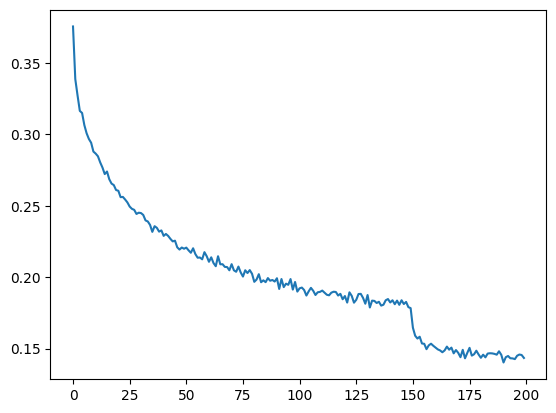

In [10]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [11]:
#transition to eval mode
for layer in model.layers:
    layer.training = False

In [12]:
#evaluation
@torch.no_grad()
def split_loss(split):
    x,y = { 'train' : (Xtr,Ytr),
        'val' : (Xdev, Ydev),
        'test' : (Xte, Yte)}[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.3531684875488281
val 2.2823760509490967


In [13]:
for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
        # forward pass
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        #if '.' comes just end word
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out)) # decode and print the generated word

koldas.
inci.
gümüşgar.
mürit.
veliyüdür.
erduru.
dalapar.
zülkif.
göksevol.
ulutaş.
alpat.
ulakbey.
alkım.
alpertunga.
durusoy.
canik.
saylav.
altınbaş.
ayanç.
şahsınur.


In [16]:
#WaveNet
#train 1.3531684875488281
#val 2.2823760509490967

#Week 4
#train 1.881050944328308
#val 2.076986074447632

#Ops we got roughly 6 times bigger net but getting worse results. #While checking gap between train and val loss we can see that WaveNet models overfit to our train data